In [1]:
from google.colab import drive
drive.mount('/content/drive')

#!wget https://zenodo.org/record/835510/files/part1_cropped.tar.gz -O /content/drive/MyDrive/icub_data/part1_cropped.tar.gz


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install -U transformers

In [2]:
import glob
import os
import shutil

import torch
from sklearn.metrics import f1_score, classification_report

from transformers import ViTImageProcessor, ViTForImageClassification, AutoModelForImageClassification, TrainingArguments, Trainer, pipeline
from datasets import load_dataset, ClassLabel

import requests

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from PIL import Image


## Local Inference on GPU
Model page: https://huggingface.co/google/vit-base-patch16-224

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/google/vit-base-patch16-224)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [4]:
# Load model directly
#from transformers import AutoImageProcessor, AutoModelForImageClassification

#processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")
#model = AutoModelForImageClassification.from_pretrained("google/vit-base-patch16-224")

Rudimentary test

In [5]:
# url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
# image = Image.open(requests.get(url, stream=True).raw)

# processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
# model_check = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')

# inputs = processor(images=image, return_tensors="pt")
# outputs = model_check(**inputs)
# logits = outputs.logits
# ##  Model predicts one of the 1000 ImageNet classes.
# predicted_class_idx = logits.argmax(-1).item()
# print("Predicted class:", model_check.config.id2label[predicted_class_idx])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Predicted class: Egyptian cat


Extract downloaded iCub dataset.

In [6]:

!rm -r /content/all_images /content/icub_dataset

!mkdir /content/all_images
!mkdir /content/icub_dataset
!ls /content/drive/MyDrive/modules_work/COMP34212/icub_data
!tar xf /content/drive/MyDrive/modules_work/COMP34212/icub_data/part1_cropped.tar.gz -C /content/icub_dataset/

part1_cropped.tar.gz  part3_cropped.tar.gz
part2_cropped.tar.gz  part4_cropped.tar.gz


In [7]:

images = glob.glob("/content/icub_dataset/**/*.jpg", recursive=True)

monolith_dir = "/content/all_images"

metadata = []


for img in images:

  #print(img)

  file_path_split = img.split('/')

  #print(file_path_split)

  label = file_path_split[4]

  filename = file_path_split[-1]

  new_filename = f"{label}_{filename}"

  print(new_filename)

  metadata = metadata + [{
      "file_name": new_filename,
      "label": label
  }]

  shutil.move(img, os.path.join(monolith_dir, new_filename))


Streaming output truncated to the last 5000 lines.
cellphone_00004180.jpg
cellphone_00004234.jpg
cellphone_00004201.jpg
cellphone_00004257.jpg
cellphone_00004355.jpg
cellphone_00004158.jpg
cellphone_00004203.jpg
cellphone_00004189.jpg
cellphone_00004225.jpg
cellphone_00004016.jpg
cellphone_00004055.jpg
cellphone_00004252.jpg
cellphone_00004032.jpg
cellphone_00004088.jpg
cellphone_00004173.jpg
cellphone_00004097.jpg
cellphone_00004050.jpg
cellphone_00004127.jpg
cellphone_00004126.jpg
cellphone_00004154.jpg
cellphone_00004245.jpg
cellphone_00004081.jpg
cellphone_00004144.jpg
cellphone_00004172.jpg
cellphone_00004121.jpg
cellphone_00004084.jpg
cellphone_00004159.jpg
cellphone_00004110.jpg
cellphone_00004021.jpg
cellphone_00004138.jpg
cellphone_00004104.jpg
cellphone_00004184.jpg
cellphone_00004030.jpg
cellphone_00004036.jpg
cellphone_00004045.jpg
cellphone_00004049.jpg
cellphone_00004087.jpg
cellphone_00004255.jpg
cellphone_00004007.jpg
cellphone_00004205.jpg
cellphone_00004015.jpg
cellph

In [8]:
##  Remove old metadata.

!rm /content/all_images/metadata.csv

##  Write new metadata.

df = pd.DataFrame(metadata)

metadata_csv = os.path.join(monolith_dir, "metadata.csv")

include_header = not os.path.exists(metadata_csv)

df.to_csv(metadata_csv,
          mode='a',
          index=False,
          header=include_header)

rm: cannot remove '/content/all_images/metadata.csv': No such file or directory


In [9]:
!head /content/all_images/metadata.csv

!tail /content/all_images/metadata.csv

file_name,label
pencilcase_00006383.jpg,pencilcase
pencilcase_00006273.jpg,pencilcase
pencilcase_00006398.jpg,pencilcase
pencilcase_00006415.jpg,pencilcase
pencilcase_00006325.jpg,pencilcase
pencilcase_00006307.jpg,pencilcase
pencilcase_00006377.jpg,pencilcase
pencilcase_00006375.jpg,pencilcase
pencilcase_00006345.jpg,pencilcase
cellphone_00002811.jpg,cellphone
cellphone_00002837.jpg,cellphone
cellphone_00002851.jpg,cellphone
cellphone_00002792.jpg,cellphone
cellphone_00002786.jpg,cellphone
cellphone_00002836.jpg,cellphone
cellphone_00002879.jpg,cellphone
cellphone_00002766.jpg,cellphone
cellphone_00002760.jpg,cellphone
cellphone_00002749.jpg,cellphone


In [10]:

dataset = load_dataset("imagefolder", data_dir="/content/all_images/")

print(dataset["train"][0])

dataset["train"] = dataset["train"].class_encode_column("label")

Resolving data files:   0%|          | 0/37345 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x7B88093DBF20>, 'label': 'pencilcase'}


Casting to class labels:   0%|          | 0/196210 [00:00<?, ? examples/s]

In [11]:
print(dataset["train"][0])

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x7B8809DB3290>, 'label': 3}


In [12]:
# ds_split = dataset["train"].train_test_split(
#     test_size=0.2,
#     seed=6948566879846,
#     stratify_by_column="label"
# )

####  **iCub World dataset categories**

PART1: book, cellphone, mouse, pencilcase, ringbinder.

PART2: hairbrush, hairclip, perfume, sunglasses, wallet.

PART3: flower, glass, mug, remote, soapdispenser.

PART4: bodylotion, ovenglove, sodabottle, sprayer, squeezer.

####  **ImageNet dataset categories**

ImageNet categories that model was trained on:

https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/

Deduce mapping between pretrained labels and dataset labels.

In [13]:
label_rename = {
    "pencilcase": "pencil case",
    "ringbinder": "ring binder",
    "soapdispenser": "dispenser",
    "bodylotion": "lotion",
    "ovenglove": "glove",
    "sodabottle": "soda",
    "mouse": "computer mouse"
    }

model_vanilla = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')

model_id_label = model_vanilla.config.id2label

model_label_id = {v: k for k, v in model_vanilla.config.id2label.items()}

ds_labels = dataset["train"].features["label"].names

print(ds_labels)

ds_labels = tuple(map(
    lambda label: label_rename[label] if label in label_rename.keys() else label,
    ds_labels
))


print(ds_labels)

ds_id_label = {i: label for i, label in enumerate(ds_labels)}

ds_label_id = {label: i for i, label in ds_id_label.items()}

print(model_id_label)
print(model_label_id)
print(ds_id_label)
print(ds_label_id)

ds_model_id_map = {}

ds_model_label_map = {}

for id, label in ds_id_label.items():

  for label_match in tuple(filter(lambda x: label in x, model_label_id.keys())):

    ds_model_label_map[label] = label_match

    ds_model_id_map[id] = model_label_id[label_match]

print(ds_model_id_map)
print(ds_model_label_map)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

['book', 'cellphone', 'mouse', 'pencilcase', 'ringbinder']
('book', 'cellphone', 'computer mouse', 'pencil case', 'ring binder')
{0: 'tench, Tinca tinca', 1: 'goldfish, Carassius auratus', 2: 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', 3: 'tiger shark, Galeocerdo cuvieri', 4: 'hammerhead, hammerhead shark', 5: 'electric ray, crampfish, numbfish, torpedo', 6: 'stingray', 7: 'cock', 8: 'hen', 9: 'ostrich, Struthio camelus', 10: 'brambling, Fringilla montifringilla', 11: 'goldfinch, Carduelis carduelis', 12: 'house finch, linnet, Carpodacus mexicanus', 13: 'junco, snowbird', 14: 'indigo bunting, indigo finch, indigo bird, Passerina cyanea', 15: 'robin, American robin, Turdus migratorius', 16: 'bulbul', 17: 'jay', 18: 'magpie', 19: 'chickadee', 20: 'water ouzel, dipper', 21: 'kite', 22: 'bald eagle, American eagle, Haliaeetus leucocephalus', 23: 'vulture', 24: 'great grey owl, great gray owl, Strix nebulosa', 25: 'European fire salamander, Salaman

Run all data through model and check for accurate predictions, calculate F1 score.

In [14]:
model_ds_id_map = {label: i for i, label in ds_model_id_map.items()}

print(model_ds_id_map)

##  Reserve class 0 for y_hats that do not match any class.

n = len(ds_id_label.keys()) + 1

##  m = len(model_id_label.keys())

f1_matrix = [[0 for _ in range(n)] for _ in range(n)]

print(f1_matrix)

image_benchmark = Image.open(requests.get(url, stream=True).raw)

print(image_benchmark)

print(ds_split["test"])

y_hat_set = []

y_set = []

{921: 0, 487: 1, 673: 2, 709: 3}
[[0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0]]
<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x480 at 0x7B8809984AA0>
Dataset({
    features: ['image', 'label'],
    num_rows: 39242
})


## **Experiment #1**

Testing model with unfamiliar dataset.

In [54]:
model_ex_1 = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [16]:
def test_model(model, testset, ds_model_id_map, model_ds_id_map, n):

  y_set, y_hat_set = [], []

  x = 0

  for img in testset:

    if x == 1000:

      break

    ##print(img)

    y = img["label"]

    if y in ds_model_id_map.keys():

      x += 1

      ##  print(ds_model_id_map[y])

      inputs = processor(img["image"], return_tensors = "pt")

      outputs = model(**inputs)

      logits = outputs.logits

      predicted_class_idx = logits.argmax(-1).item()

      ##  Convert to y_hat via dataset category id.

      if predicted_class_idx not in model_ds_id_map.keys():

          y_hat = n - 1

      else:

          y_hat = model_ds_id_map[predicted_class_idx]

      ##  f1_matrix[y_hat][y] += 1

      y_hat_set = y_hat_set + [y_hat]

      y_set = y_set + [y]

      ##  print(f"{x}\t{y}\t{y_hat}")

  return y_set, y_hat_set

In [17]:
def calc_f1(y_set: list[int], y_hat_set: list[int]):

  f1 = f1_score(y_set, y_hat_set, average=None)

  f1_weighted = f1_score(y_set, y_hat_set, average="weighted")

  return f1, f1_weighted

New dataset, pretrained model, no finetuning.

In [ ]:
experiment_1_done = False

if experiment_1_done == False:

  y_set_ex_1, y_hat_set_ex_1 = test_model(model_ex_1,
                                ds_split["test"],
                                ds_model_id_map,
                                model_ds_id_map,
                                len(ds_id_label.keys()) + 1)


  print(y_set_ex_1)

  print(y_hat_set_ex_1)

In [ ]:
if experiment_1_done == False:

  report = classification_report(
      y_set_ex_1,
      y_hat_set_ex_1,
      output_dict=False
  )

  ##print(calc_f1(y_set_ex_1, y_hat_set_ex_1))

  print(model_ds_id_map)


  print(report)

Note that the above F1-scores are reproducible with the upcoming batch-based test sequence used in Experiment \#2 and onwards, such as by setting thet training epochs to 0.

## **Experiment #2**

New dataset, pretrained model, finetuning experimenting.

In [20]:
def transform_label_v2(examples):

  new_labels = list(map(
      lambda l: ds_model_id_map[l] if l in ds_model_id_map else 1,
      examples["label"]
  ))

  updated_examples = {
      "labels": new_labels,
      "image": examples["image"]
  }

  if 'pixel_values' in examples:
      updated_examples['pixel_values'] = examples['pixel_values']

  return updated_examples


In [34]:
print(dataset["train"][0])
print(dataset["train"])

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x7B87F2AE4290>, 'label': 3}
Dataset({
    features: ['image', 'label'],
    num_rows: 196210
})


In [22]:
def create_iterator(start_val):

  counter = start_val

  def incrementer():
      nonlocal counter
      counter += 1
      return counter

  return incrementer


def transform_img(examples):

  ##  print(examples)

  print(train_iter())

  ##  Convert image format to tensor format, accepted by training process.

  inputs = processor(
      [img.convert("RGB") for img in examples["image"]],
      return_tensors = "pt"
      )

  inputs["labels"] = examples["label"]

  return inputs


def transform_label(examples):

  ##  print('examples', examples)

  ##  Convert labels to ImageNet equivalents.

  new_labels = list(map(
      lambda l: ds_model_id_map[l] if l in ds_model_id_map else 1,
      examples["label"]
  ))

  ##  print(examples["label"])

  ##  print(new_labels)

  inputs["labels"] = new_labels

  return inputs

Filter iCub World dataset to retrieve only data points for which a corresponding label exists in the original ImageNet dataset the model was trained on. This prevents the training of data for which no corresponding class exists.

In [36]:
ds_subset_filtered = dataset_filtered["train"].train_test_split(
 test_size = 0.2,
 stratify_by_column = "label",
 seed = 6948566879846,
)

#  Trains OK.
ds_subset_train_img = ds_subset["train"].with_transform(transform_img)
ds_subset_test_img = ds_subset["test"].with_transform(transform_img)

#  Trains OK.
ds_subset_filt_train_img = ds_subset_filtered["train"].with_transform(transform_img)
ds_subset_filt_test_img = ds_subset_filtered["test"].with_transform(transform_img)

NameError: name 'dataset_filtered' is not defined

In [37]:
dataset_filtered = dataset.filter(lambda d: d["label"] in ds_model_id_map.keys())

Filter:   0%|          | 0/196210 [00:00<?, ? examples/s]

Adjust the labels of the data to match the ImageNet dataset.

Also run the images through the image processor.

In [38]:
print(pd.DataFrame(dataset_filtered["train"].shuffle(seed=3954385)[:10]))

print(dataset_filtered)

                                               image  label
0  <PIL.JpegImagePlugin.JpegImageFile image mode=...      2
1  <PIL.JpegImagePlugin.JpegImageFile image mode=...      1
2  <PIL.JpegImagePlugin.JpegImageFile image mode=...      3
3  <PIL.JpegImagePlugin.JpegImageFile image mode=...      0
4  <PIL.JpegImagePlugin.JpegImageFile image mode=...      3
5  <PIL.JpegImagePlugin.JpegImageFile image mode=...      2
6  <PIL.JpegImagePlugin.JpegImageFile image mode=...      1
7  <PIL.JpegImagePlugin.JpegImageFile image mode=...      2
8  <PIL.JpegImagePlugin.JpegImageFile image mode=...      0
9  <PIL.JpegImagePlugin.JpegImageFile image mode=...      1
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 161145
    })
})


In [39]:
ds_subset_filtered = dataset_filtered["train"].train_test_split(
  #train_size = 20,
  test_size = 0.2,
  seed = 6948566879846,
  stratify_by_column = "label"
)

In [40]:
##  OK as of 19/03/2026 10:41am.
ds_subset_filt_train_img_relabel = ds_subset_filtered["train"].with_transform(transform_img).with_transform(transform_label)

##  Split again for validation and test sets.
ds_subset_filt_testvalid_img_relabel = ds_subset_filtered["test"].train_test_split(
  train_size = 0.5,
  test_size = 0.5,
  seed = 6948566879846,
  stratify_by_column = "label"
)

ds_subset_filt_validation_img_relabel = ds_subset_filt_testvalid_img_relabel["train"].with_transform(transform_img).with_transform(transform_label)

print(dataset_filtered)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 161145
    })
})


In [41]:
print(ds_subset_filt_train_img_relabel)

Dataset({
    features: ['image', 'label'],
    num_rows: 128916
})


Fine-tune model. Note that the HuggingFace library will default to GPU.

In [42]:
##  print(ds_split["train"][0])

train_iter = create_iterator(0)

model_ex_2 = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224'
)

training_args = TrainingArguments(
    output_dir = "/content/model_ex_2",
    num_train_epochs = 8,               ##  Frequency of times to feed training data.
    per_device_train_batch_size = 256,  ##  Batch size when training.
    gradient_accumulation_steps = 8,    ##  Delay before backpropagation.
    gradient_checkpointing = True,      ##  More on-the-fly during backpropagation.
    learning_rate = 2e-5,               ##  The rate of parameter iteration.
    logging_steps = 10,                 ##  How often to update loss function.
    eval_strategy = "epoch",            ##  Run evaluation at end of epoch.
    save_strategy = "epoch",            ##  Save at end of each epoch.
    load_best_model_at_end = True,      ##  Load best model at end, via evaluations.
    remove_unused_columns = False,
)

trainer = Trainer(
    model = model_ex_2,
    args = training_args,
    train_dataset = ds_subset_filt_train_img_relabel,
    eval_dataset = ds_subset_filt_validation_img_relabel,
    ##  processing_class = tokenizer,
    ##  data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

print("Training with device:", trainer.args.device)

experiment_2_train_done = False

if experiment_2_train_done == False:

  trainer.train()

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Training with device: cuda:0


Epoch,Training Loss,Validation Loss
1,1.516123,1.474500
2,1.498021,1.564961
3,1.482858,1.443204
4,1.440639,1.478156
5,1.546751,1.409694
6,1.415676,1.426351
7,1.419451,1.401914
8,1.393005,1.395200


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

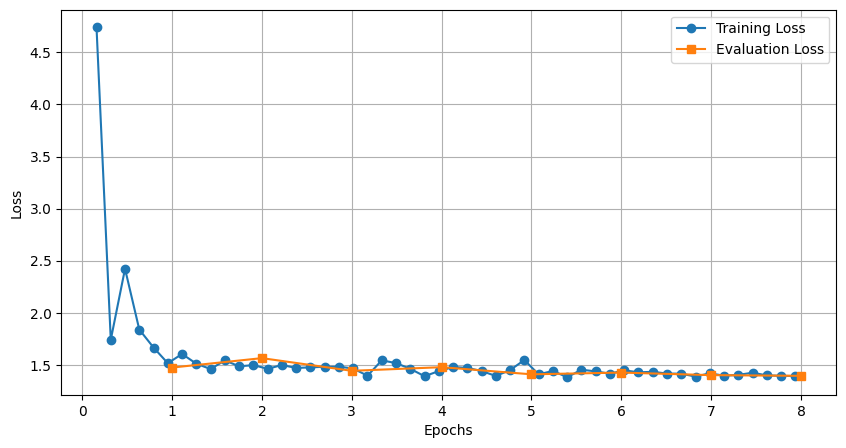

In [53]:
# 1. Convert log history to a Pandas DataFrame
history = pd.DataFrame(trainer.state.log_history)

# 2. Separate training and evaluation logs
# Training logs usually have 'loss', eval logs have 'eval_loss'
train_loss = history[history['loss'].notna()]
eval_loss = history[history['eval_loss'].notna()]

plt.figure(figsize=(10, 5))

# Plotting Training Loss
plt.plot(train_loss['epoch'], train_loss['loss'], label='Training Loss', marker='o')

# Plotting Evaluation Loss
plt.plot(eval_loss['epoch'], eval_loss['eval_loss'], label='Evaluation Loss', marker='s')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig("ex_2_loss_func.pdf", format="pdf")

In [44]:
def test_model_ex_2(m_classifier, processor, testset):

  y_set, y_hat_set = [], []

  pipe = pipeline(
      "image-classification",
      model = m_classifier,
      image_processor = processor,
      torch_dtype = torch.float16
      )

  for i, out in enumerate(pipe(data_generator(testset), batch_size=256)):

    y_hat_label = out[0]['label']

    y_hat = pipe.model.config.label2id[y_hat_label]

    y = testset[i]['labels']

    print(i)

    ##  print(y_hat, y)

    print(y, y_hat)

    y_set = y_set + [y]

    y_hat_set = y_hat_set + [y_hat]

  return y_set, y_hat_set


def data_generator(testset):
    for sample in testset:
        # For ViT, we yield the PIL image object directly
        yield sample["image"]




In [50]:
ds_subset_filt_test_img_relabel = ds_subset_filt_testvalid_img_relabel["test"].with_transform(transform_label_v2)

print(dataset_filtered)


experiment_2_test_done = False

if experiment_2_test_done == False:

  y_set_ex_2, y_hat_set_ex_2 = test_model_ex_2(
      model_ex_2,
      ViTImageProcessor.from_pretrained('google/vit-base-patch16-224'),
      ds_subset_filt_test_img_relabel
      )

  f1_each, f1_weighted = calc_f1(y_set, y_hat_set)

Streaming output truncated to the last 5000 lines.
13615
709 764
13616
921 921
13617
921 921
13618
673 543
13619
921 624
13620
921 921
13621
673 673
13622
673 673
13623
673 673
13624
487 487
13625
673 673
13626
487 487
13627
921 613
13628
487 590
13629
673 673
13630
487 487
13631
673 543
13632
709 453
13633
487 438
13634
709 788
13635
673 673
13636
709 747
13637
921 624
13638
921 921
13639
709 748
13640
673 543
13641
921 921
13642
921 898
13643
709 764
13644
673 673
13645
709 655
13646
921 499
13647
487 487
13648
709 954
13649
487 487
13650
709 788
13651
921 624
13652
921 655
13653
921 860
13654
487 487
13655
921 585
13656
487 761
13657
709 709
13658
921 413
13659
487 487
13660
487 487
13661
709 612
13662
709 788
13663
709 673
13664
921 921
13665
487 761
13666
487 761
13667
921 624
13668
921 624
13669
673 673
13670
487 487
13671
709 709
13672
921 626
13673
487 487
13674
921 527
13675
673 882
13676
921 480
13677
921 674
13678
487 487
13679
709 636
13680
487 673
13681
709 699
13682
921 7

In [51]:
f1_each, f1_weighted = calc_f1(y_set, y_hat_set)

report = classification_report(
    y_set_ex_2,
    y_hat_set_ex_2,
    output_dict=False
)

print(report)

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         0
          36       0.00      0.00      0.00         0
          60       0.00      0.00      0.00         0
          61       0.00      0.00      0.00         0
          62       0.00      0.00      0.00         0
          63       0.00      0.00      0.00         0
          69       0.00      0.00      0.00         0
         120       0.00      0.00      0.00         0
         122       0.00      0.00      0.00         0
         183       0.00      0.00      0.00         0
         377       0.00      0.00      0.00         0
         389       0.00      0.00      0.00         0
         391       0.00      0.00      0.00         0
         395       0.00      0.00      0.00         0
         398       0.00      0.00      0.00         0
         399       0.00      0.00      0.00         0
         400       0.00      0.00      0.00         0
         401       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
##  To detect what hardware model is running on.

print(next(model_ex_2.parameters()).dtype)
for name, param in model_ex_2.named_parameters():
    print(f"Layer: {name} | Dtype: {param.dtype} | Device: {param.device}")

## **Experiment #3**

Fine-tuning class with best F1 score.

In [25]:
ds_673_filtered = dataset.filter(lambda d: d["label"] == model_ds_id_map[673])

Filter:   0%|          | 0/196210 [00:00<?, ? examples/s]

In [26]:
ds_673_first_split = ds_673_filtered["train"].train_test_split(
  test_size = 0.2,
  seed = 6948566879846,
  stratify_by_column = "label"
)

ds_673_train = ds_673_first_split["train"].with_transform(transform_img).with_transform(transform_label)

##  Split again for validation and test sets.

ds_673_second_split = ds_673_first_split["test"].train_test_split(
  train_size = 0.5,
  test_size = 0.5,
  seed = 6948566879846,
  stratify_by_column = "label"
)

ds_673_validation = ds_673_second_split["train"].with_transform(transform_img).with_transform(transform_label)

ds_673_test = ds_673_second_split["test"].with_transform(transform_label_v2)

In [27]:
print(ds_673_filtered)
print(ds_673_train)
print(ds_673_test)

print(pd.DataFrame(ds_673_first_split["train"].shuffle(seed=3954385)[:10]))

print(pd.DataFrame(ds_673_second_split["train"].shuffle(seed=3954385)[:10]))

print(ds_673_train[0])

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 42811
    })
})
Dataset({
    features: ['image', 'label'],
    num_rows: 34248
})
Dataset({
    features: ['image', 'label'],
    num_rows: 4282
})
                                               image  label
0  <PIL.JpegImagePlugin.JpegImageFile image mode=...      2
1  <PIL.JpegImagePlugin.JpegImageFile image mode=...      2
2  <PIL.JpegImagePlugin.JpegImageFile image mode=...      2
3  <PIL.JpegImagePlugin.JpegImageFile image mode=...      2
4  <PIL.JpegImagePlugin.JpegImageFile image mode=...      2
5  <PIL.JpegImagePlugin.JpegImageFile image mode=...      2
6  <PIL.JpegImagePlugin.JpegImageFile image mode=...      2
7  <PIL.JpegImagePlugin.JpegImageFile image mode=...      2
8  <PIL.JpegImagePlugin.JpegImageFile image mode=...      2
9  <PIL.JpegImagePlugin.JpegImageFile image mode=...      2
                                               image  label
0  <PIL.JpegImagePlugin.JpegImageFile im

In [28]:
train_iter = create_iterator(0)

model_ex_3 = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224'
)

training_args_ex_3 = TrainingArguments(
    output_dir = "/content/model_ex_3",
    num_train_epochs = 8,               ##  Frequency of times to feed training data.
    per_device_train_batch_size = 16,   ##  Batch size when training.
    per_device_eval_batch_size = 4,     ##  Batch size when training.
    gradient_accumulation_steps = 32,   ##  Delay before backpropagation.
    gradient_checkpointing = True,      ##  More on-the-fly during backpropagation.
    learning_rate = 2e-5,               ##  The rate of parameter iteration.
    logging_steps = 10,                 ##  How often to update loss function.
    eval_strategy = "epoch",            ##  Run evaluation at end of epoch.
    save_strategy = "epoch",            ##  Save at end of each epoch.
    load_best_model_at_end = True,      ##  Load best model at end, via evaluations.
    remove_unused_columns = False,
)

trainer_ex_3 = Trainer(
    model = model_ex_3,
    args = training_args_ex_3,
    train_dataset = ds_673_train,
    eval_dataset = ds_673_validation,
    ##  processing_class = tokenizer,
    ##  data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

print("Training with device:", trainer_ex_3.args.device)

experiment_3_train_done = False

if experiment_3_train_done == False:

  trainer_ex_3.train()

else:

  pass

  #trainer_ex_3.train(resume_from_checkpoint='/content/model_ex_3')

  #model_ex_3 = AutoModelForImageClassification.from_pretrained('/content/model_ex_3')

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Training with device: cuda:0


Epoch,Training Loss,Validation Loss
1,0.001985,0.001586
2,0.000815,0.000751
3,0.000491,0.000472
4,0.000361,0.000341
5,0.000274,0.000264
6,0.000219,0.000214
7,0.000186,0.000180
8,0.000159,0.000155
9,0.000138,0.000136


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# 1. Convert log history to a Pandas DataFrame
history = pd.DataFrame(trainer_ex_3.state.log_history)

# 2. Separate training and evaluation logs
# Training logs usually have 'loss', eval logs have 'eval_loss'
train_loss = history[history['loss'].notna()]
eval_loss = history[history['eval_loss'].notna()]

plt.figure(figsize=(10, 5))

# Plotting Training Loss
plt.plot(train_loss['epoch'], train_loss['loss'], label='Training Loss', marker='o')

# Plotting Evaluation Loss
plt.plot(eval_loss['epoch'], eval_loss['eval_loss'], label='Evaluation Loss', marker='s')

plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig("ex_3_loss_func.pdf", format="pdf")
plt.show()


In [31]:


experiment_3_test_done = False

if experiment_3_test_done == False:

  y_set_ex_3, y_hat_set_ex_3 = test_model_ex_2(
      model_ex_3,
      ViTImageProcessor.from_pretrained('google/vit-base-patch16-224'),
      ds_673_test
      )

  f1_each_ex_3, f1_weighted_ex_3 = calc_f1(y_set, y_hat_set)


`torch_dtype` is deprecated! Use `dtype` instead!


Streaming output truncated to the last 5000 lines.
1782
673 487
1783
673 543
1784
673 673
1785
673 543
1786
673 543
1787
673 837
1788
673 747
1789
673 673
1790
673 673
1791
673 673
1792
673 543
1793
673 543
1794
673 673
1795
673 673
1796
673 673
1797
673 543
1798
673 673
1799
673 487
1800
673 543
1801
673 673
1802
673 543
1803
673 673
1804
673 673
1805
673 673
1806
673 613
1807
673 673
1808
673 673
1809
673 788
1810
673 590
1811
673 673
1812
673 673
1813
673 673
1814
673 788
1815
673 662
1816
673 673
1817
673 673
1818
673 673
1819
673 543
1820
673 826
1821
673 543
1822
673 613
1823
673 673
1824
673 673
1825
673 673
1826
673 673
1827
673 673
1828
673 543
1829
673 673
1830
673 673
1831
673 662
1832
673 673
1833
673 673
1834
673 543
1835
673 673
1836
673 673
1837
673 590
1838
673 673
1839
673 613
1840
673 673
1841
673 673
1842
673 543
1843
673 761
1844
673 673
1845
673 673
1846
673 543
1847
673 613
1848
673 487
1849
673 673
1850
673 543
1851
673 543
1852
673 673
1853
673 543
1854
673 543


In [32]:
if experiment_3_test_done == False:

  report = classification_report(
    y_set_ex_3,
    y_hat_set_ex_3,
    output_dict=False
  )

  print(f1_each_ex_3, f1_weighted_ex_3)

  print(report)

[] nan
              precision    recall  f1-score   support

          47       0.00      0.00      0.00         0
          60       0.00      0.00      0.00         0
          61       0.00      0.00      0.00         0
          62       0.00      0.00      0.00         0
         118       0.00      0.00      0.00         0
         120       0.00      0.00      0.00         0
         122       0.00      0.00      0.00         0
         362       0.00      0.00      0.00         0
         401       0.00      0.00      0.00         0
         422       0.00      0.00      0.00         0
         438       0.00      0.00      0.00         0
         440       0.00      0.00      0.00         0
         447       0.00      0.00      0.00         0
         453       0.00      0.00      0.00         0
         464       0.00      0.00      0.00         0
         473       0.00      0.00      0.00         0
         480       0.00      0.00      0.00         0
         482       0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## **Experiment #4**

Fine-tuning class with worst F1 score.

In [ ]:
ds_709_filtered = dataset.filter(lambda d: d["label"] == model_ds_id_map[709])

In [ ]:
ds_709_first_split = ds_709_filtered["train"].train_test_split(
  test_size = 0.2,
  seed = 6948566879846,
  stratify_by_column = "label"
)

ds_709_train = ds_709_first_split["train"].with_transform(transform_img).with_transform(transform_label)

##  Split again for validation and test sets.

ds_709_second_split = ds_709_first_split["test"].train_test_split(
  train_size = 0.5,
  test_size = 0.5,
  seed = 6948566879846,
  stratify_by_column = "label"
)

ds_709_validation = ds_709_second_split["train"].with_transform(transform_img).with_transform(transform_label)

ds_709_test = ds_709_second_split["test"].with_transform(transform_label_v2)

In [ ]:
print(ds_709_filtered)
print(ds_709_train)
print(ds_709_test)

print(pd.DataFrame(ds_709_first_split["train"].shuffle(seed=3954385)[:10]))

print(pd.DataFrame(ds_709_second_split["train"].shuffle(seed=3954385)[:10]))

In [ ]:
train_iter = create_iterator(0)

model_ex_4 = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224'
)

training_args_ex_4 = TrainingArguments(
    output_dir = "/content/model_ex_4",
    num_train_epochs = 32,               ##  Frequency of times to feed training data.
    per_device_train_batch_size = 16,   ##  Batch size when training.
    per_device_eval_batch_size = 4,     ##  Batch size when training.
    gradient_accumulation_steps = 32,   ##  Delay before backpropagation.
    gradient_checkpointing = True,      ##  More on-the-fly during backpropagation.
    learning_rate = 2e-5,               ##  The rate of parameter iteration.
    logging_steps = 10,                 ##  How often to update loss function.
    eval_strategy = "epoch",            ##  Run evaluation at end of epoch.
    save_strategy = "epoch",            ##  Save at end of each epoch.
    load_best_model_at_end = True,      ##  Load best model at end, via evaluations.
    remove_unused_columns = False,
)



trainer_ex_4 = Trainer(
    model = model_ex_4,
    args = training_args_ex_4,
    train_dataset = ds_709_train,
    eval_dataset = ds_709_validation,
    ##  processing_class = tokenizer,
    ##  data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

print("Training with device:", trainer.args.device)

trainer_ex_4.train()

In [ ]:

# 1. Convert log history to a Pandas DataFrame
history = pd.DataFrame(trainer_ex_4.state.log_history)

# 2. Separate training and evaluation logs
# Training logs usually have 'loss', eval logs have 'eval_loss'
train_loss = history[history['loss'].notna()]
eval_loss = history[history['eval_loss'].notna()]

plt.figure(figsize=(10, 5))

# Plotting Training Loss
plt.plot(train_loss['epoch'], train_loss['loss'], label='Training Loss', marker='o')

# Plotting Evaluation Loss
plt.plot(eval_loss['epoch'], eval_loss['eval_loss'], label='Evaluation Loss', marker='s')

plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig("ex_4_loss_func.pdf", format="pdf")

In [ ]:

experiment_4_test_done = True

if experiment_4_test_done == False:

  y_set_ex_4, y_hat_set_ex_4 = test_model_ex_2(
      model_ex_3,
      ViTImageProcessor.from_pretrained('google/vit-base-patch16-224'),
      ds_709_test
      )

  f1_each_ex_4, f1_weighted_ex_4 = calc_f1(y_set, y_hat_set)

report = classification_report(
    y_set_ex_4,
    y_hat_set_ex_4,
    output_dict=False
)